In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv("Financialdata_Feature_Engineered.csv")

In [2]:
features = [
    "Gross_Margin",
    "Net_Profit_Margin",
    "ROA",
    "ROE",
    "Debt_to_Assets",
    "Debt_to_Equity",
    "Asset_Turnover",
    "Financial_Health_Score"
]
features = [col for col in features if col in df.columns]
cluster_data = df[features]
print(cluster_data.head())

   Gross_Margin  Net_Profit_Margin     ROE  Debt_to_Assets  Debt_to_Equity  \
0     37.053483           7.137770  0.1664          0.2455        0.506100   
1     24.865715           3.637315  0.3294          0.2274        1.509300   
2     37.053483           7.137770  0.2821          0.3863        2.100700   
3     37.053483           4.291641 -0.1180          0.8290       -1.436475   
4     37.053483           7.137770  0.2792          0.3796        1.344500   

   Financial_Health_Score  
0               13.932032  
1                8.109223  
2               13.960957  
3               13.149400  
4               13.960232  


In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

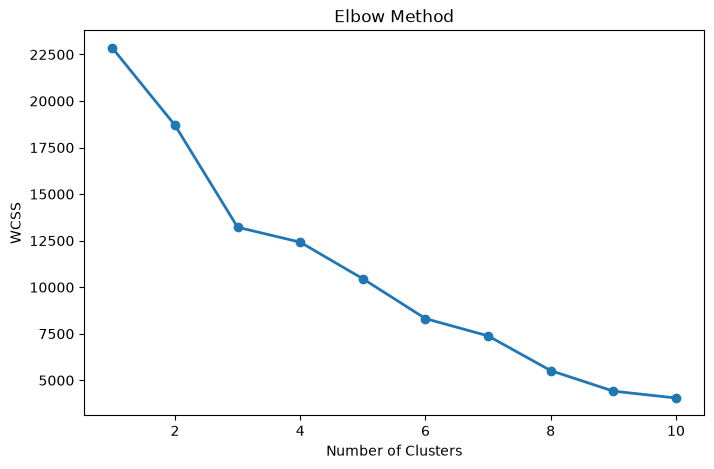

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)   # <-- note the underscore

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linewidth=2)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
df["Cluster"] = kmeans.fit_predict(scaled_data)
print(df["Cluster"].value_counts())

Cluster
1    2648
0    1157
2       2
3       1
Name: count, dtype: int64


/var/folders/17/8v92bh8j1s99htpdmdhp3vy00000gn/T/ipykernel_2055/384661115.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Cluster"] = kmeans.fit_predict(scaled_data)


In [9]:
cluster_summary = df.groupby("Cluster")[features].mean()
print(cluster_summary)

         Gross_Margin  Net_Profit_Margin       ROE  Debt_to_Assets  \
Cluster                                                              
0           50.940135         -48.391809  0.116754        0.464110   
1           57.531272        -356.653393  0.034266        0.119581   
2          100.000000     -227950.909091 -0.242050        0.000000   
3       -22348.275862      -46065.517241  0.302400        0.303100   

         Debt_to_Equity  Financial_Health_Score  
Cluster                                          
0              1.505391               -7.872336  
1              0.219847             -170.704650  
2              0.000000          -137720.855967  
3             -0.090900           -24076.648538  


/var/folders/17/8v92bh8j1s99htpdmdhp3vy00000gn/T/ipykernel_2055/732671111.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PCA1"] = pca_components[:,0]
/var/folders/17/8v92bh8j1s99htpdmdhp3vy00000gn/T/ipykernel_2055/732671111.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PCA2"] = pca_components[:,1]


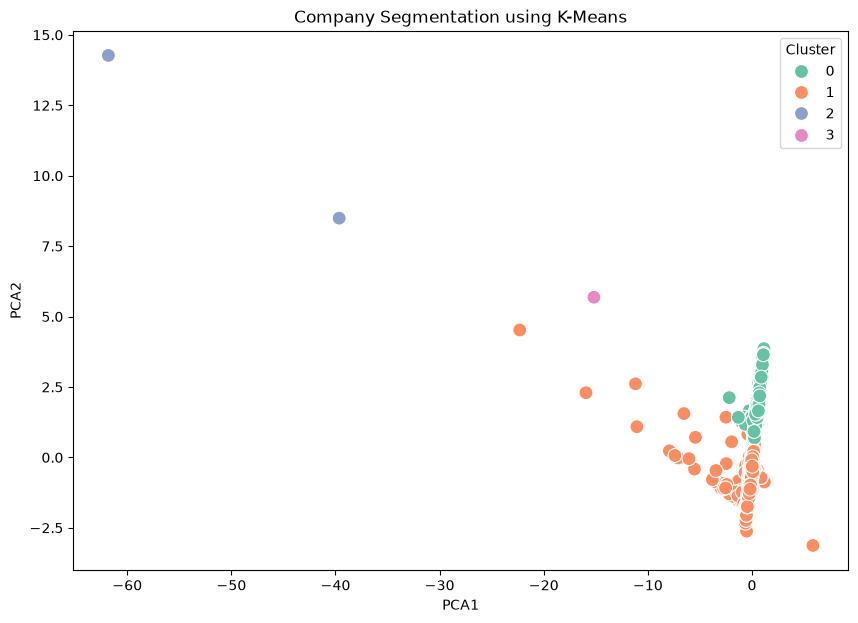

In [10]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_data)

df["PCA1"] = pca_components[:,0]
df["PCA2"] = pca_components[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("Company Segmentation using K-Means")

plt.show()

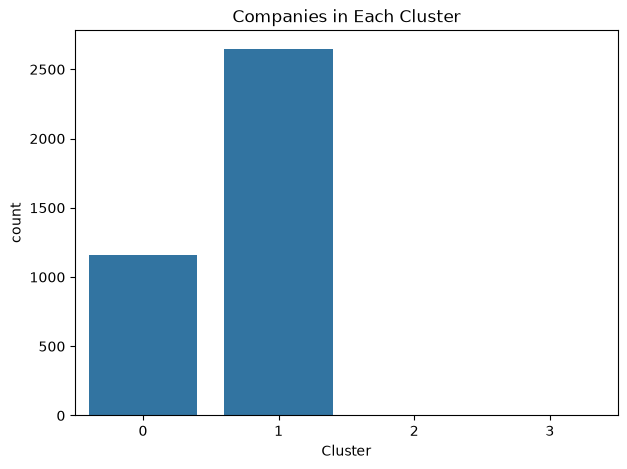

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cluster"
)
plt.title("Companies in Each Cluster")
plt.show()

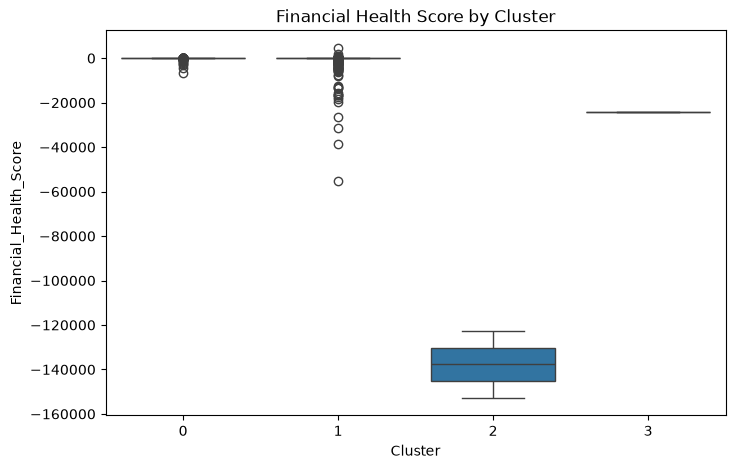

In [12]:
if "Financial_Health_Score" in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="Cluster",
        y="Financial_Health_Score"
    )

    plt.title("Financial Health Score by Cluster")

    plt.show()

Revenue_Category  High  Low  Medium  Very High
Cluster                                       
0                  359  155     250        393
1                  571  794     724        559
2                    0    2       0          0
3                    0    1       0          0


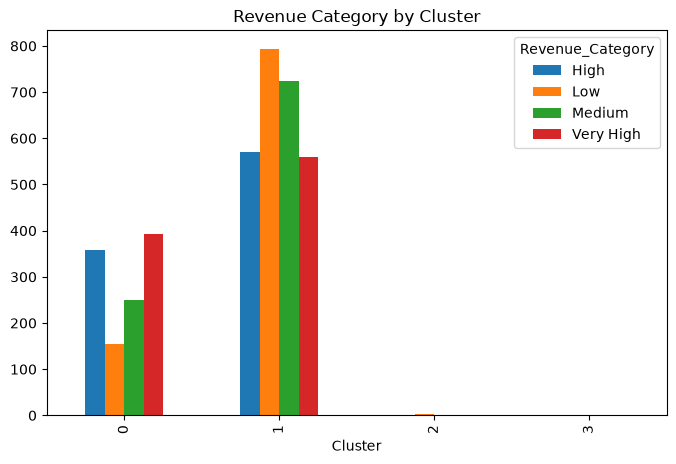

In [13]:
if {"Revenue_Category","Cluster"}.issubset(df.columns):

    cross = pd.crosstab(
        df["Cluster"],
        df["Revenue_Category"]
    )

    print(cross)

    cross.plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title("Revenue Category by Cluster")

    plt.show()

In [14]:
cluster_names = {
    0: "High Growth",
    1: "Financially Stable",
    2: "High Debt",
    3: "Underperforming"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

print(df[["Cluster","Cluster_Name"]].head())

   Cluster        Cluster_Name
0        1  Financially Stable
1        0         High Growth
2        0         High Growth
3        1  Financially Stable
4        0         High Growth


/var/folders/17/8v92bh8j1s99htpdmdhp3vy00000gn/T/ipykernel_2055/3761610272.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Cluster_Name"] = df["Cluster"].map(cluster_names)


In [15]:
df.to_csv(
    "Financialdata_Segmented.csv",
    index=False
)
print("Company Segmentation Completed Successfully!")

Company Segmentation Completed Successfully!
